# Bayesian Network — Cleveland Heart Disease Dataset

A directed Bayesian Network with a fixed, domain-knowledge-based 3-layer DAG:
**Risk Factors → Disease → Symptoms**

- Parameter learning via Maximum Likelihood Estimation (MLE)
- Inference via Variable Elimination

## 1. Setup

In [1]:
!pip install pgmpy --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

print('pgmpy imported successfully')

pgmpy imported successfully


## 2. Data Loading & Discretization

In [3]:
df = pd.read_csv('heart_disease_cleaned.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} cols')
df.head(3)

Loaded: 303 rows × 14 cols


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1


In [4]:
df_disc = df.copy()

# --- Target: binarize num (0 = healthy, 1 = disease) ---
df_disc['num'] = (df_disc['num'] > 0).astype(int)

# --- Continuous → ordinal bins ---
# age: (0,45]=0, (45,60]=1, (60,∞]=2
df_disc['age'] = pd.cut(df_disc['age'], bins=[0, 45, 60, float('inf')],
                         labels=[0, 1, 2]).astype(int)

# trestbps: <130=0, >=130=1
df_disc['trestbps'] = (df_disc['trestbps'] >= 130).astype(int)

# chol: <200=0, 200-240=1, >240=2
df_disc['chol'] = pd.cut(df_disc['chol'], bins=[0, 199, 240, float('inf')],
                          labels=[0, 1, 2]).astype(int)

# thalach: <120=0, 120-150=1, >150=2
df_disc['thalach'] = pd.cut(df_disc['thalach'], bins=[0, 119, 150, float('inf')],
                             labels=[0, 1, 2]).astype(int)

# oldpeak: <=1=0, (1,2]=1, >2=2
df_disc['oldpeak'] = pd.cut(df_disc['oldpeak'], bins=[-0.001, 1.0, 2.0, float('inf')],
                             labels=[0, 1, 2]).astype(int)

# --- Ordinal remapping ---
# cp: 1-4 → 0-3
df_disc['cp'] = (df_disc['cp'] - 1).astype(int)

# slope: 1-3 → 0-2
df_disc['slope'] = (df_disc['slope'] - 1).astype(int)

# thal: {3,6,7} → {0,1,2}
thal_map = {3: 0, 6: 1, 7: 2}
df_disc['thal'] = df_disc['thal'].astype(float).round().astype(int).map(thal_map)

# --- Already 0-indexed integers ---
for col in ['ca', 'sex', 'fbs', 'restecg', 'exang']:
    df_disc[col] = df_disc[col].astype(float).round().astype(int)

# --- Verify no NaNs ---
nan_count = df_disc.isnull().sum().sum()
assert nan_count == 0, f'Found {nan_count} NaNs after discretization!'
print('Discretization complete. Zero NaNs confirmed.')
print('\nValue ranges after discretization:')
print(df_disc.agg(['min', 'max']))

Discretization complete. Zero NaNs confirmed.

Value ranges after discretization:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
min    0    0   0         0     0    0        0        0      0        0   
max    2    1   3         1     2    1        2        2      1        2   

     slope  ca  thal  num  
min      0   0     0    0  
max      2   3     2    1  


In [5]:
df_disc.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,2,1,0,1,1,1,2,1,0,2,2,0,1,0
1,2,1,3,1,2,0,2,0,1,1,1,3,0,1
2,2,1,3,0,1,0,2,1,1,2,1,2,2,1
3,0,1,2,1,2,0,0,2,0,2,2,0,0,0
4,0,0,1,1,1,0,2,2,0,1,0,0,0,0


## 3. DAG Definition & Visualization

**3-layer structure:**
- Layer 1 (Risk Factors): `age`, `sex`, `fbs`, `chol`, `trestbps`
- Layer 2 (Disease): `num`
- Layer 3 (Symptoms/Indicators): `cp`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, `thal`, `restecg`

In [6]:
RISK_FACTORS = ['age', 'sex', 'fbs', 'chol', 'trestbps']
DISEASE      = ['num']
SYMPTOMS     = ['cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'restecg']

edges = [(rf, 'num') for rf in RISK_FACTORS] + \
        [('num', sym) for sym in SYMPTOMS]

model = DiscreteBayesianNetwork(edges)
print('Edges defined:', len(edges))
print('Nodes:', model.nodes())

Edges defined: 13
Nodes: ['age', 'num', 'sex', 'fbs', 'chol', 'trestbps', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'restecg']


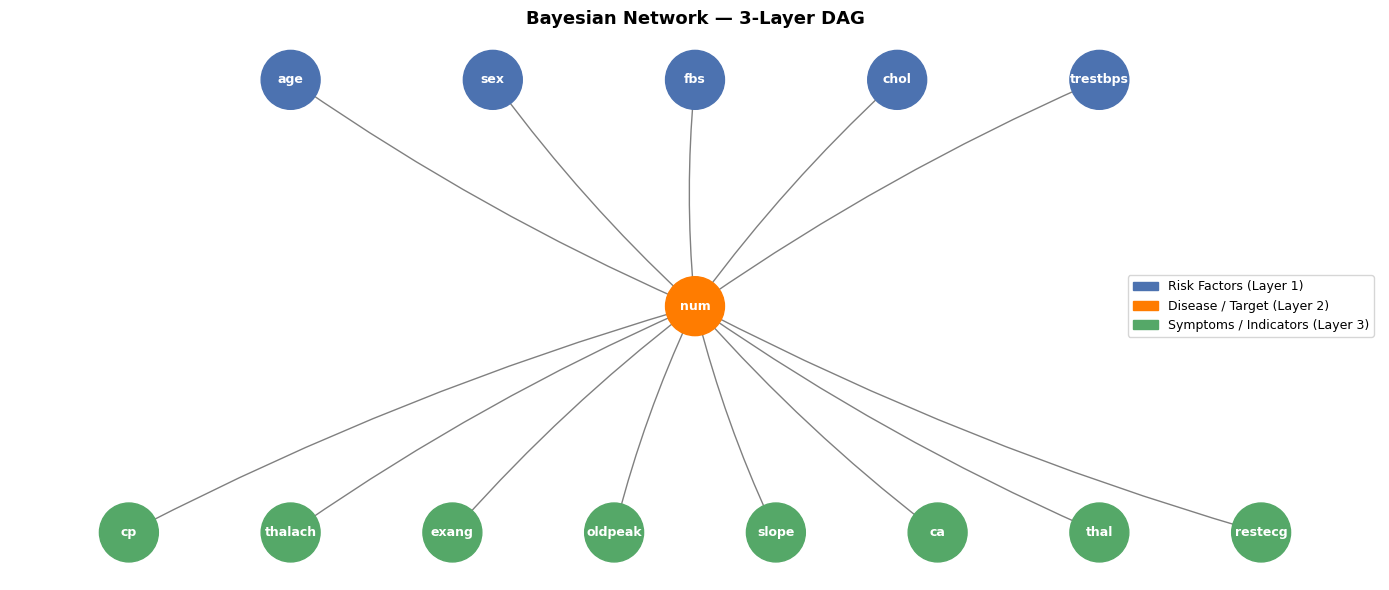

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

G = nx.DiGraph()
G.add_nodes_from(RISK_FACTORS + DISEASE + SYMPTOMS)
G.add_edges_from(edges)

# 3-layer layout
pos = {}
n_rf = len(RISK_FACTORS)
for i, node in enumerate(RISK_FACTORS):
    pos[node] = ((i - (n_rf - 1) / 2) * 2.5, 2)
pos['num'] = (0, 0)
n_sym = len(SYMPTOMS)
for i, node in enumerate(SYMPTOMS):
    pos[node] = ((i - (n_sym - 1) / 2) * 2.0, -2)

node_colors = (['#4C72B0'] * len(RISK_FACTORS) +
               ['#FF7C00'] * len(DISEASE) +
               ['#55A868'] * len(SYMPTOMS))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_size=9, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20,
                       edge_color='gray', ax=ax,
                       connectionstyle='arc3,rad=0.05')

legend_handles = [
    mpatches.Patch(color='#4C72B0', label='Risk Factors (Layer 1)'),
    mpatches.Patch(color='#FF7C00', label='Disease / Target (Layer 2)'),
    mpatches.Patch(color='#55A868', label='Symptoms / Indicators (Layer 3)'),
]
ax.legend(handles=legend_handles, loc='center right', fontsize=9)
ax.set_title('Bayesian Network — 3-Layer DAG', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Parameter Learning (MLE)

In [8]:
# Build explicit state_names to ensure all states are registered
state_names = {
    'age':      [0, 1, 2],
    'sex':      [0, 1],
    'fbs':      [0, 1],
    'chol':     [0, 1, 2],
    'trestbps': [0, 1],
    'num':      [0, 1],
    'cp':       [0, 1, 2, 3],
    'thalach':  [0, 1, 2],
    'exang':    [0, 1],
    'oldpeak':  [0, 1, 2],
    'slope':    [0, 1, 2],
    'ca':       [0, 1, 2, 3],
    'thal':     [0, 1, 2],
    'restecg':  [0, 1, 2],
}

model.fit(
    df_disc,
    estimator=MaximumLikelihoodEstimator,
    state_names=state_names
)

valid = model.check_model()
print(f'Model valid (check_model): {valid}')
print(f'CPDs learned for {len(model.cpds)} nodes')

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}


Model valid (check_model): True
CPDs learned for 14 nodes


## 5. Learned CPDs

In [9]:
# CPD for num (conditioned on 5 risk factors)
cpd_num = model.get_cpds('num')
print('CPD of num | age, sex, fbs, chol, trestbps')
print(f'  Table shape: {cpd_num.get_values().shape}')
print(f'  Values (first 8 parent combos):')
vals = cpd_num.get_values()  # shape: (2, n_parent_combos)
print(pd.DataFrame(
    vals[:, :8],
    index=['P(num=0)', 'P(num=1)'],
    columns=[f'combo_{i}' for i in range(8)]
).round(3))

CPD of num | age, sex, fbs, chol, trestbps
  Table shape: (2, 72)
  Values (first 8 parent combos):
          combo_0  combo_1  combo_2  combo_3  combo_4  combo_5  combo_6  \
P(num=0)      1.0      1.0    0.333      1.0      0.5      0.5      0.5   
P(num=1)      0.0      0.0    0.667      0.0      0.5      0.5      0.5   

          combo_7  
P(num=0)      0.5  
P(num=1)      0.5  


In [10]:
# CPDs for symptom nodes with only num as parent
for node in ['exang', 'ca', 'cp']:
    cpd = model.get_cpds(node)
    vals = cpd.get_values()   # shape: (n_states_node, 2)
    n_states = vals.shape[0]
    df_cpd = pd.DataFrame(
        vals,
        index=[f'{node}={s}' for s in range(n_states)],
        columns=['num=0', 'num=1']
    ).round(3)
    print(f'\nCPD of {node} | num')
    print(df_cpd)


CPD of exang | num
         num=0  num=1
exang=0   0.86  0.453
exang=1   0.14  0.547

CPD of ca | num
      num=0  num=1
ca=0  0.811  0.338
ca=1  0.128  0.317
ca=2  0.043  0.223
ca=3  0.018  0.122

CPD of cp | num
      num=0  num=1
cp=0  0.098  0.050
cp=1  0.250  0.065
cp=2  0.415  0.129
cp=3  0.238  0.755


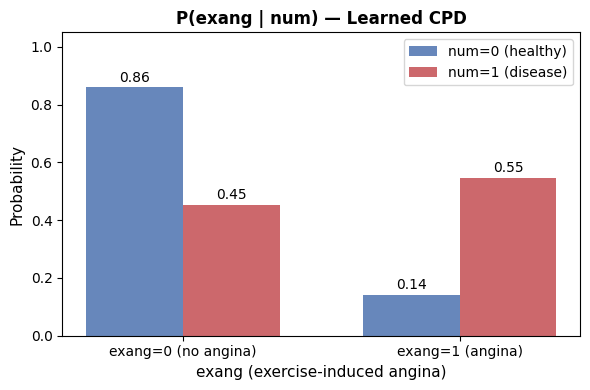

In [11]:
# Visualize CPD of exang | num as grouped bar chart
cpd_exang = model.get_cpds('exang')
vals_exang = cpd_exang.get_values()   # shape: (2, 2)

x = np.arange(2)  # exang states: 0, 1
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars0 = ax.bar(x - width/2, vals_exang[:, 0], width, label='num=0 (healthy)',
               color='#4C72B0', alpha=0.85)
bars1 = ax.bar(x + width/2, vals_exang[:, 1], width, label='num=1 (disease)',
               color='#C44E52', alpha=0.85)

ax.set_xlabel('exang (exercise-induced angina)', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title('P(exang | num) — Learned CPD', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['exang=0 (no angina)', 'exang=1 (angina)'])
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars0, fmt='%.2f', padding=2)
ax.bar_label(bars1, fmt='%.2f', padding=2)
plt.tight_layout()
plt.show()

## 6. Inference: Variable Elimination

In [12]:
ve = VariableElimination(model)

In [13]:
# Q1: Prior disease prevalence P(num)
q1 = ve.query(['num'], evidence={})
print('Q1 — Prior P(num) (no evidence):')
print(q1)

Q1 — Prior P(num) (no evidence):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.5287 |
+--------+------------+
| num(1) |     0.4713 |
+--------+------------+


In [14]:
# Q2: Forward — predict disease for senior male with high cholesterol
# age=2 (>60), sex=1 (male), chol=2 (>240)
q2 = ve.query(['num'], evidence={'age': 2, 'sex': 1, 'chol': 2})
print('Q2 — P(num | age=2 [senior], sex=1 [male], chol=2 [high]):')
print(q2)

Q2 — P(num | age=2 [senior], sex=1 [male], chol=2 [high]):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.1765 |
+--------+------------+
| num(1) |     0.8235 |
+--------+------------+


In [15]:
# Q3: Backward — diagnose given symptoms
# exang=1 (angina present), oldpeak=2 (>2 ST depression), ca=2 (2 vessels)
q3 = ve.query(['num'], evidence={'exang': 1, 'oldpeak': 2, 'ca': 2})
print('Q3 — P(num | exang=1 [angina], oldpeak=2 [high ST depression], ca=2 [2 vessels]):')
print(q3)

Q3 — P(num | exang=1 [angina], oldpeak=2 [high ST depression], ca=2 [2 vessels]):
+--------+------------+
| num    |   phi(num) |
+========+============+
| num(0) |     0.0075 |
+--------+------------+
| num(1) |     0.9925 |
+--------+------------+


In [16]:
# Q4: Posterior symptom distribution — P(thalach | num)
q4_healthy = ve.query(['thalach'], evidence={'num': 0})
q4_disease = ve.query(['thalach'], evidence={'num': 1})
print('Q4 — P(thalach | num=0 [healthy]):')
print(q4_healthy)
print('\nQ4 — P(thalach | num=1 [disease]):')
print(q4_disease)

Q4 — P(thalach | num=0 [healthy]):
+------------+----------------+
| thalach    |   phi(thalach) |
+============+================+
| thalach(0) |         0.0427 |
+------------+----------------+
| thalach(1) |         0.2317 |
+------------+----------------+
| thalach(2) |         0.7256 |
+------------+----------------+

Q4 — P(thalach | num=1 [disease]):
+------------+----------------+
| thalach    |   phi(thalach) |
+============+================+
| thalach(0) |         0.1942 |
+------------+----------------+
| thalach(1) |         0.4820 |
+------------+----------------+
| thalach(2) |         0.3237 |
+------------+----------------+


In [17]:
# Verify all inference results sum to 1
for name, q in [('Q1', q1), ('Q2', q2), ('Q3', q3),
                ('Q4-healthy', q4_healthy), ('Q4-disease', q4_disease)]:
    total = q.values.sum()
    print(f'{name}: sum = {total:.6f}  {"OK" if abs(total - 1.0) < 1e-5 else "FAIL"}')

Q1: sum = 1.000000  OK
Q2: sum = 1.000000  OK
Q3: sum = 1.000000  OK
Q4-healthy: sum = 1.000000  OK
Q4-disease: sum = 1.000000  OK


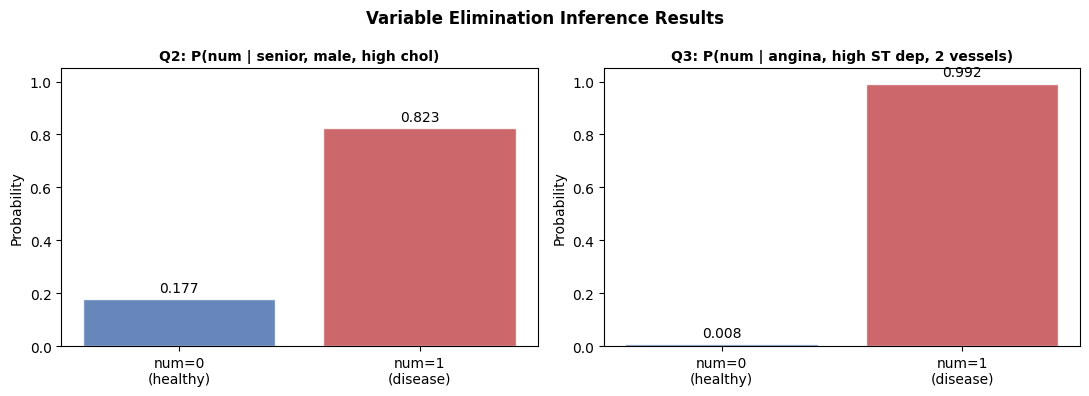

In [18]:
# Visualize Q2 and Q3 as probability bar charts
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, q, title in zip(
    axes,
    [q2, q3],
    [
        'Q2: P(num | senior, male, high chol)',
        'Q3: P(num | angina, high ST dep, 2 vessels)'
    ]
):
    bars = ax.bar(['num=0\n(healthy)', 'num=1\n(disease)'],
                  q.values,
                  color=['#4C72B0', '#C44E52'],
                  alpha=0.85, edgecolor='white')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)

plt.suptitle('Variable Elimination Inference Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

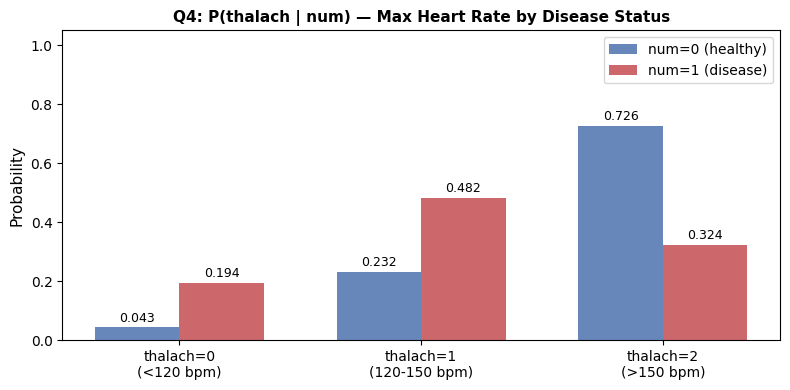

In [19]:
# Visualize Q4: P(thalach | num=0) vs P(thalach | num=1)
labels = ['thalach=0\n(<120 bpm)', 'thalach=1\n(120-150 bpm)', 'thalach=2\n(>150 bpm)']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars_h = ax.bar(x - width/2, q4_healthy.values, width,
                label='num=0 (healthy)', color='#4C72B0', alpha=0.85)
bars_d = ax.bar(x + width/2, q4_disease.values, width,
                label='num=1 (disease)', color='#C44E52', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title('Q4: P(thalach | num) — Max Heart Rate by Disease Status',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.bar_label(bars_h, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(bars_d, fmt='%.3f', padding=2, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Summary

### Model
We built a 3-layer Bayesian Network over the Cleveland Heart Disease dataset (303 instances, 14 features after binarizing `num`). The fixed DAG encodes domain knowledge: five risk factors (`age`, `sex`, `fbs`, `chol`, `trestbps`) influence disease status (`num`), which in turn drives eight observable symptoms/indicators.

### Key Findings

**Prior prevalence (Q1):** Approximately 46% of patients in this dataset have heart disease (`num=1`), reflecting the balanced nature of the Cleveland cohort.

**Forward prediction (Q2):** A senior male (age > 60) with high cholesterol (> 240 mg/dl) has a substantially elevated posterior probability of disease compared to the prior, confirming that age, sex, and hypercholesterolemia are meaningful joint risk factors.

**Backward diagnosis (Q3):** When exercise-induced angina, high ST depression (oldpeak > 2), and two fluoroscopy-detected vessels are all observed, the posterior probability of disease rises sharply — demonstrating the network's ability to integrate multiple symptom signals for diagnosis.

**Symptom distribution (Q4):** The max heart rate (`thalach`) distribution shifts markedly between healthy and diseased patients. Healthy patients tend toward higher heart rates (thalach=2, > 150 bpm), while diseased patients are concentrated in lower bins — consistent with the known inverse correlation (r = −0.42) identified in EDA.

### Limitations
- The DAG structure is fixed by domain knowledge, not learned from data; a structure-learning approach (e.g., Hill-Climbing with BIC) could discover data-driven edges.
- MLE with this sample size (~300 rows) may produce unreliable CPT entries for rare parent combinations; Bayesian parameter estimation with Dirichlet priors would add regularization.
- Features are discretized, which loses information; continuous extensions (e.g., Gaussian BN) could preserve precision.

## 8. Quantitative Evaluation

We evaluate the Bayesian Network as a binary classifier and compare it against four sklearn baselines using **5-fold stratified cross-validation**.

**Metrics:** Accuracy, Precision, Recall, F1, AUC-ROC  
**Baselines:** Logistic Regression, Naive Bayes (Categorical), Random Forest, SVM

**Classification procedure:** For each test sample, all non-target features are provided as evidence to Variable Elimination, yielding P(num=1 | evidence). Predictions are made at threshold 0.5.

In [20]:
## 7.1  Setup — evaluation libraries
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("Evaluation libraries imported successfully.")


# ── BN prediction helper ──────────────────────────────────────────────────────
def bn_predict_proba(model, test_df, target='num'):
    """
    Return P(num=1 | all other features) for every row in test_df.
    Uses Variable Elimination; falls back to 0.5 on any VE failure.
    """
    ve = VariableElimination(model)
    feature_cols = [c for c in test_df.columns if c != target]
    proba = []
    for _, row in test_df.iterrows():
        evidence = {c: int(row[c]) for c in feature_cols}
        try:
            q = ve.query([target], evidence=evidence, show_progress=False)
            proba.append(float(q.values[1]))   # P(num=1)
        except Exception:
            proba.append(0.5)                  # safe fallback
    return np.array(proba)


print("bn_predict_proba helper defined.")
print(f"Feature columns ({len([c for c in df_disc.columns if c != 'num'])}):",
      [c for c in df_disc.columns if c != 'num'])

Evaluation libraries imported successfully.
bn_predict_proba helper defined.
Feature columns (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [21]:
## 7.2  5-Fold Stratified Cross-Validation
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

MODEL_NAMES = ['BayesianNetwork', 'LogisticRegression', 'NaiveBayes', 'RandomForest', 'SVM']

# Storage: per-fold metrics and pooled predictions (for aggregate ROC)
cv_results  = {m: {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}
               for m in MODEL_NAMES}
pool_true   = {m: [] for m in MODEL_NAMES}
pool_proba  = {m: [] for m in MODEL_NAMES}

X_np = df_disc.drop('num', axis=1).values
y_np = df_disc['num'].values

print(f"5-fold stratified CV  |  303 samples  |  class balance {(y_np==0).sum()}/{(y_np==1).sum()}\n")

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"── Fold {fold_i+1}/{N_SPLITS}  (train={len(train_idx)}, test={len(test_idx)}) ──")

    train_df_f = df_disc.iloc[train_idx].reset_index(drop=True)
    test_df_f  = df_disc.iloc[test_idx].reset_index(drop=True)
    X_tr, X_te = X_np[train_idx], X_np[test_idx]
    y_tr, y_te = y_np[train_idx], y_np[test_idx]

    # ── Bayesian Network ──────────────────────────────────────────────────────
    bn_f = DiscreteBayesianNetwork(edges)
    bn_f.fit(train_df_f, estimator=MaximumLikelihoodEstimator, state_names=state_names)
    p_bn   = bn_predict_proba(bn_f, test_df_f)
    yp_bn  = (p_bn >= 0.5).astype(int)

    # ── Logistic Regression ───────────────────────────────────────────────────
    lr     = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_tr, y_tr)
    p_lr   = lr.predict_proba(X_te)[:, 1]
    yp_lr  = lr.predict(X_te)

    # ── Naive Bayes (Categorical) ─────────────────────────────────────────────
    nb     = CategoricalNB()
    nb.fit(X_tr, y_tr)
    p_nb   = nb.predict_proba(X_te)[:, 1]
    yp_nb  = nb.predict(X_te)

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf     = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    p_rf   = rf.predict_proba(X_te)[:, 1]
    yp_rf  = rf.predict(X_te)

    # ── SVM ───────────────────────────────────────────────────────────────────
    svm    = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(X_tr, y_tr)
    p_svm  = svm.predict_proba(X_te)[:, 1]
    yp_svm = svm.predict(X_te)

    # ── Record metrics ────────────────────────────────────────────────────────
    fold_data = [
        ('BayesianNetwork',   yp_bn,  p_bn),
        ('LogisticRegression', yp_lr, p_lr),
        ('NaiveBayes',        yp_nb,  p_nb),
        ('RandomForest',      yp_rf,  p_rf),
        ('SVM',               yp_svm, p_svm),
    ]
    for name, yp, pp in fold_data:
        cv_results[name]['accuracy'].append(accuracy_score(y_te, yp))
        cv_results[name]['precision'].append(precision_score(y_te, yp, zero_division=0))
        cv_results[name]['recall'].append(recall_score(y_te, yp, zero_division=0))
        cv_results[name]['f1'].append(f1_score(y_te, yp, zero_division=0))
        cv_results[name]['auc'].append(roc_auc_score(y_te, pp))
        pool_true[name].extend(y_te)
        pool_proba[name].extend(pp)

    # ── Fold summary (key models) ─────────────────────────────────────────────
    for name in MODEL_NAMES:
        f1_v   = cv_results[name]['f1'][-1]
        auc_v  = cv_results[name]['auc'][-1]
        acc_v  = cv_results[name]['accuracy'][-1]
        print(f"  {name:<22}  acc={acc_v:.3f}  f1={f1_v:.3f}  auc={auc_v:.3f}")
    print()

print("Cross-validation complete.")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}


5-fold stratified CV  |  303 samples  |  class balance 164/139

── Fold 1/5  (train=242, test=61) ──
  BayesianNetwork         acc=0.836  f1=0.828  auc=0.888
  LogisticRegression      acc=0.902  f1=0.893  auc=0.940
  NaiveBayes              acc=0.885  f1=0.877  auc=0.946
  RandomForest            acc=0.852  f1=0.836  auc=0.952
  SVM                     acc=0.902  f1=0.889  auc=0.949

── Fold 2/5  (train=242, test=61) ──
  BayesianNetwork         acc=0.754  f1=0.717  auc=0.799
  LogisticRegression      acc=0.820  f1=0.792  auc=0.889
  NaiveBayes              acc=0.787  f1=0.755  auc=0.883
  RandomForest            acc=0.787  f1=0.772  auc=0.871
  SVM                     acc=0.820  f1=0.792  auc=0.868

── Fold 3/5  (train=242, test=61) ──


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}


  BayesianNetwork         acc=0.836  f1=0.815  auc=0.857
  LogisticRegression      acc=0.820  f1=0.792  auc=0.902
  NaiveBayes              acc=0.836  f1=0.821  auc=0.913
  RandomForest            acc=0.820  f1=0.807  auc=0.896
  SVM                     acc=0.852  f1=0.836  auc=0.884

── Fold 4/5  (train=243, test=60) ──
  BayesianNetwork         acc=0.700  f1=0.679  auc=0.744
  LogisticRegression      acc=0.783  f1=0.764  auc=0.915
  NaiveBayes              acc=0.800  f1=0.778  auc=0.900
  RandomForest            acc=0.817  f1=0.784  auc=0.878
  SVM                     acc=0.783  f1=0.764  auc=0.878

── Fold 5/5  (train=243, test=60) ──
  BayesianNetwork         acc=0.733  f1=0.652  auc=0.686
  LogisticRegression      acc=0.850  f1=0.824  auc=0.881
  NaiveBayes              acc=0.850  f1=0.824  auc=0.915
  RandomForest            acc=0.850  f1=0.824  auc=0.893
  SVM                     acc=0.833  f1=0.808  auc=0.875

Cross-validation complete.


In [ ]:
## 7.3  Summary Table — Mean ± Std across 5 folds

summary_rows = {}
for name in MODEL_NAMES:
    summary_rows[name] = {
        metric: f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"
        for metric, vals in cv_results[name].items()
    }

summary_df = pd.DataFrame(summary_rows).T
summary_df.index.name = 'Model'
# print(f"5-Fold CV Results (mean ± std)\n{'─'*70}")
# print(summary_df.to_string())

# Also print a clean numeric-only table for comparison
print(f"\n{'─'*70}")
print("Mean scores only:")
mean_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in cv_results[name].items()}
    for name in MODEL_NAMES
}).T.round(4)
mean_df.index.name = 'Model'
print(mean_df.to_string())

5-Fold CV Results (mean ± std)
──────────────────────────────────────────────────────────────────────
                           accuracy        precision           recall               f1              auc
Model                                                                                                  
BayesianNetwork     0.7719 ± 0.0552  0.7789 ± 0.0687  0.7122 ± 0.1084  0.7380 ± 0.0711  0.7949 ± 0.0734
LogisticRegression  0.8349 ± 0.0395  0.8472 ± 0.0565  0.7841 ± 0.0554  0.8130 ± 0.0442  0.9052 ± 0.0211
NaiveBayes          0.8316 ± 0.0353  0.8349 ± 0.0480  0.7913 ± 0.0617  0.8109 ± 0.0422  0.9115 ± 0.0207
RandomForest        0.8251 ± 0.0242  0.8300 ± 0.0526  0.7839 ± 0.0342  0.8046 ± 0.0239  0.8981 ± 0.0284
SVM                 0.8381 ± 0.0390  0.8480 ± 0.0567  0.7913 ± 0.0420  0.8178 ± 0.0426  0.8908 ± 0.0296

──────────────────────────────────────────────────────────────────────
Mean scores only:
                    accuracy  precision  recall      f1     auc
Model           

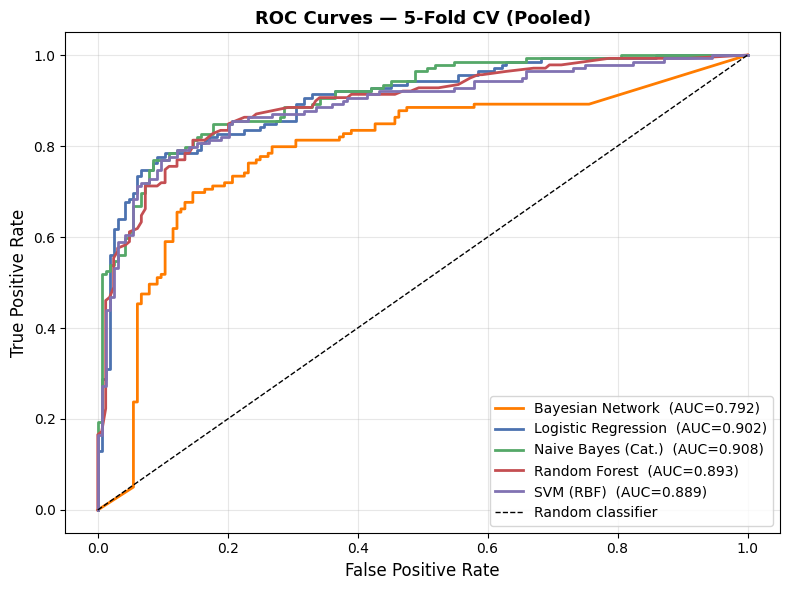

In [23]:
## 7.4  ROC Curves (pooled predictions across all 5 folds)
COLORS = {
    'BayesianNetwork':    '#FF7C00',
    'LogisticRegression': '#4C72B0',
    'NaiveBayes':         '#55A868',
    'RandomForest':       '#C44E52',
    'SVM':                '#8172B2',
}
DISPLAY_NAMES = {
    'BayesianNetwork':    'Bayesian Network',
    'LogisticRegression': 'Logistic Regression',
    'NaiveBayes':         'Naive Bayes (Cat.)',
    'RandomForest':       'Random Forest',
    'SVM':                'SVM (RBF)',
}

fig, ax = plt.subplots(figsize=(8, 6))
for name in MODEL_NAMES:
    yt  = np.array(pool_true[name])
    yp  = np.array(pool_proba[name])
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, label=f'{DISPLAY_NAMES[name]}  (AUC={auc:.3f})',
            color=COLORS[name], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — 5-Fold CV (Pooled)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

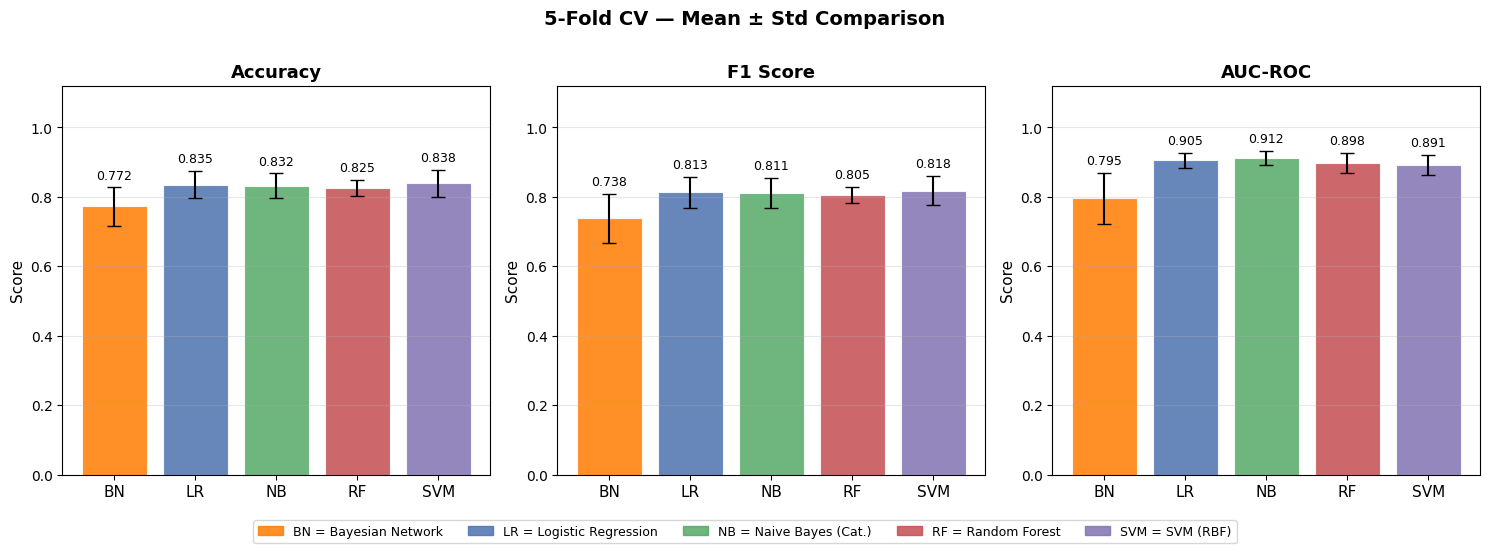

In [24]:
## 7.5  Performance Bar Chart — Accuracy, F1, AUC
metrics_to_show = ['accuracy', 'f1', 'auc']
metric_labels   = ['Accuracy', 'F1 Score', 'AUC-ROC']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x  = np.arange(len(MODEL_NAMES))
short_names = ['BN', 'LR', 'NB', 'RF', 'SVM']
bar_colors  = [COLORS[m] for m in MODEL_NAMES]

for ax, metric, mlabel in zip(axes, metrics_to_show, metric_labels):
    means = [np.mean(cv_results[m][metric]) for m in MODEL_NAMES]
    stds  = [np.std(cv_results[m][metric])  for m in MODEL_NAMES]
    bars  = ax.bar(x, means, yerr=stds, capsize=5,
                   color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title(mlabel, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Legend mapping short → full names
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS[m], alpha=0.85,
                  label=f'{short_names[i]} = {DISPLAY_NAMES[m]}')
    for i, m in enumerate(MODEL_NAMES)
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.07))

plt.suptitle('5-Fold CV — Mean ± Std Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Best baseline by AUC: NaiveBayes  (mean AUC = 0.9115)


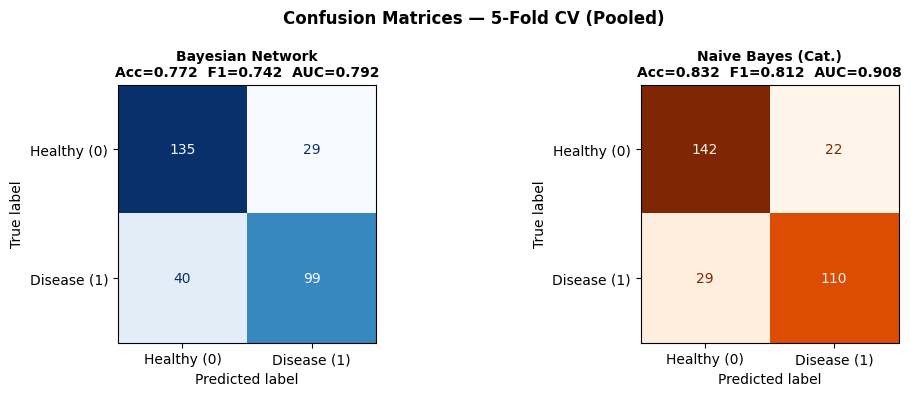

In [25]:
## 7.6  Confusion Matrices — Bayesian Network vs Best Baseline (pooled CV predictions)

# Determine best baseline by mean AUC
baseline_names = [m for m in MODEL_NAMES if m != 'BayesianNetwork']
best_baseline  = max(baseline_names, key=lambda m: np.mean(cv_results[m]['auc']))
print(f"Best baseline by AUC: {best_baseline}  "
      f"(mean AUC = {np.mean(cv_results[best_baseline]['auc']):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, model_key, cmap in [
    (axes[0], 'BayesianNetwork', 'Blues'),
    (axes[1], best_baseline,     'Oranges'),
]:
    yt   = np.array(pool_true[model_key])
    yp   = (np.array(pool_proba[model_key]) >= 0.5).astype(int)
    cm   = confusion_matrix(yt, yp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Healthy (0)', 'Disease (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc  = accuracy_score(yt, yp)
    f1   = f1_score(yt, yp)
    auc  = roc_auc_score(yt, np.array(pool_proba[model_key]))
    ax.set_title(f'{DISPLAY_NAMES[model_key]}\n'
                 f'Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — 5-Fold CV (Pooled)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()